In [1]:
import numpy as np
from scipy.optimize import approx_fprime
import matplotlib.pyplot as plt

## 1. Gradient Descent Function: 

In [2]:
def gradient_descent(f, x0, max_iter=1000, lr=0.01, lr_schedule='constant', tol=1e-6):
    """
    Minimize f: R^q -> R via gradient descent.

    Parameters
    ----------
    f           : callable, the function to minimize
    x0          : numpy array, starting point
    max_iter    : int, maximum number of iterations
    lr          : float, base learning rate (gamma)
    lr_schedule : str, one of 'constant', 'decay', 'sqrt_decay'
    tol         : float, stopping tolerance on gradient norm

    Returns
    -------
    x        : numpy array, the approximate minimizer found
    f_values : list of floats, function values at each iteration
    path     : list of numpy arrays, sequence of iterates visited
    """
    # Store the initial point as an array of floats
    x = np.array(x0, dtype=float)
    # Small perturbation for numerical gradient (square root of machine epsilon)
    epsilon = np.sqrt(np.finfo(float).eps)

    # To store the path of iterates and function values
    path = [x.copy()]
    f_values = [f(x)]

    for m in range(1, max_iter + 1):
        # Step 1: compute gradient numerically at the current point
        grad = approx_fprime(x, f, epsilon)

        # Stopping criterion: if gradient is nearly zero, we are at a (local) minimum
        if np.linalg.norm(grad) < tol:
            break

        # Step 2: choose learning rate gamma_m for this iteration
        if lr_schedule == 'constant':
            gamma = lr
        elif lr_schedule == 'decay':
            # Inverse decay: gamma_m = lr / m  (cf. notes Section 2.6.2: gamma_m = 1/m)
            gamma = lr / m
        elif lr_schedule == 'sqrt_decay':
            # Inverse square-root decay: slower decrease than 1/m
            gamma = lr / np.sqrt(m)
        else:
            raise ValueError(f"Unknown lr_schedule: {lr_schedule}")

        # Step 3: gradient descent update x_{m+1} = x_m - gamma_m * grad(f(x_m))
        x = x - gamma * grad

        # Record the new iterate and its function value
        path.append(x.copy())
        f_values.append(f(x))

    print(f"Converged in {m} iterations")
    return x, f_values, path

## 2. Test Functions definition: 

In [3]:
# Lévi function N.13
def f_xy(v):
    """
    v : array-like of shape (2,) -> [x, y]
    Returns the value of the function.
    """
    x, y = v[0], v[1]

    term1 = np.sin(3 * np.pi * x)**2
    term2 = (x - 1)**2 * (1 + np.sin(3 * np.pi * y)**2)
    term3 = (y - 1)**2 * (1 + np.sin(2 * np.pi * y)**2)

    return term1 + term2 + term3


# Three hump camel (min in (0,0))
def f_camel(x):
    return 2*x[0]**2-1.05*x[0]**4+x[0]**6/6+x[0]*x[1]+x[1]**2


## 3. Run Gradient Descent on Hump Camel

Converged in 500 iterations
Three-hump camel | start=[3 4] -> found min at [-0.0003  0.0008], f=0.000001
Converged in 500 iterations
Three-hump camel | start=[-2  2] -> found min at [-1.7476  0.8739], f=0.298638
Converged in 500 iterations
Three-hump camel | start=[0 5] -> found min at [-1.7476  0.8739], f=0.298638


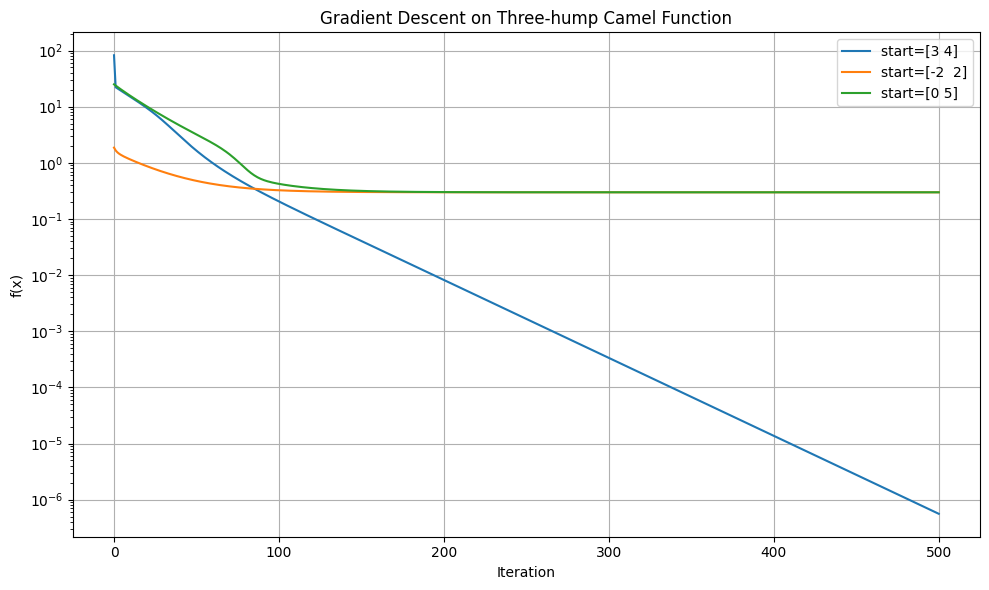

In [4]:
# Starting points
starts = [np.array([3, 4]), np.array([-2, 2]), np.array([0, 5])]

plt.figure(figsize=(10, 6))

for x0 in starts:
    x_min, f_vals, path = gradient_descent(f_camel, x0, max_iter=500, lr=0.01)
    plt.plot(f_vals, label=f'start={x0}')
    print(f"Three-hump camel | start={x0} -> found min at {np.round(x_min, 4)}, f={f_camel(x_min):.6f}")

plt.xlabel('Iteration')
plt.ylabel('f(x)')
plt.title('Gradient Descent on Three-hump Camel Function')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 4. Run Gradient Descent on Levi Function


Converged in 500 iterations
Lévi N.13 | start=[3 4] -> found min at [2.9776 0.8831], f=7.086218
Converged in 500 iterations
Lévi N.13 | start=[-2  2] -> found min at [-1.2914  0.5844], f=8.187399
Converged in 65 iterations
Lévi N.13 | start=[0 5] -> found min at [0.0141 2.3898], f=3.958551


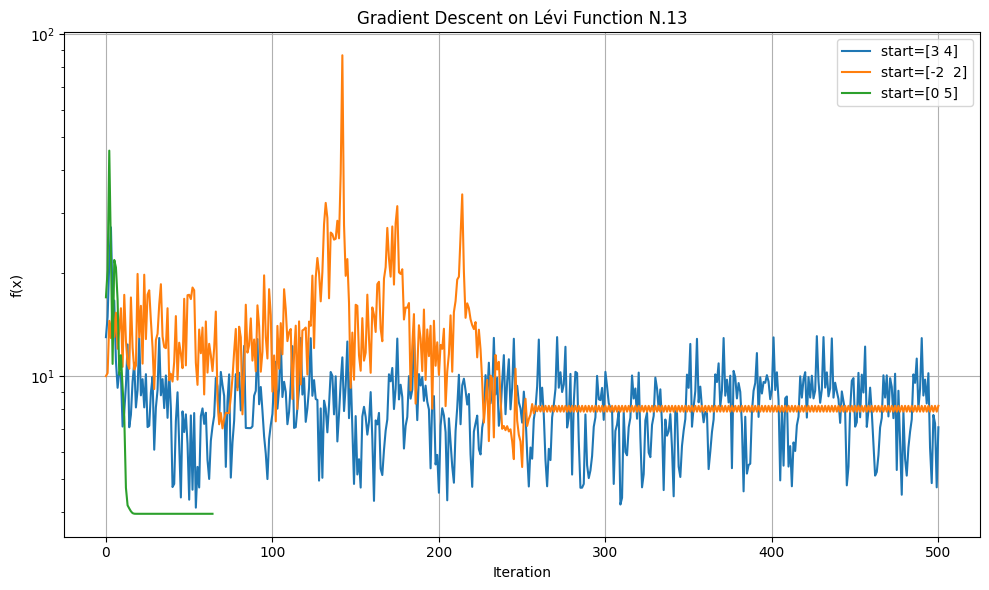

In [5]:
# Lévi function N.13
plt.figure(figsize=(10, 6))

for x0 in starts:
    x_min, f_vals, path = gradient_descent(f_xy, x0, max_iter=500, lr=0.01)
    plt.plot(f_vals, label=f'start={x0}')
    print(f"Lévi N.13 | start={x0} -> found min at {np.round(x_min, 4)}, f={f_xy(x_min):.6f}")

plt.xlabel('Iteration')
plt.ylabel('f(x)')
plt.title('Gradient Descent on Lévi Function N.13')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In this case we can observe an obscillating behaviour since it has a multimodal shape, due to the presence of sin. For this reason, the path shows an increase in the values f(x) and then a decrease. The observed lack of convergence seems to result from the joint effect of the maximum iteration limit and the gradient-norm stopping rule. Either criterion may cause premature termination, preventing the algorithm from fully approaching the minimum. A more careful tuning of these parameters or the inclusion of complementary stopping conditions may therefore be necessary
Instead, in the three-hump camel function there is an homogeneous behaviour in the gradient descent algorithm since the function is similar to a quadratic function, so the path to reach the minimum is smoother.

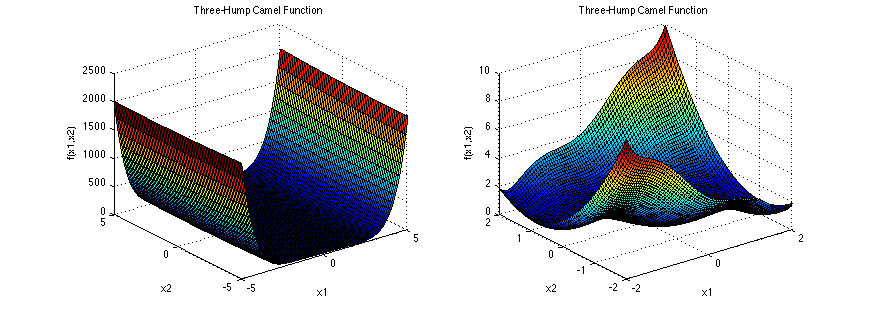

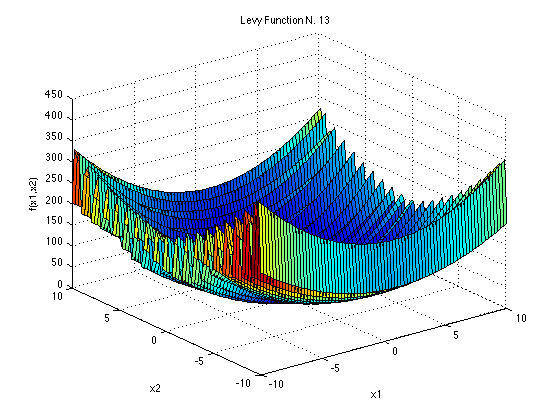

Converged in 500 iterations
Converged in 500 iterations
Converged in 130 iterations


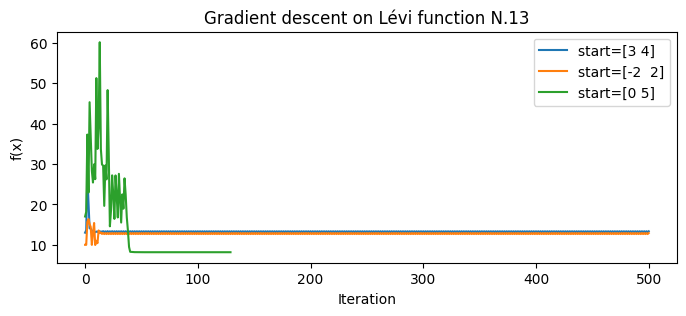

In [6]:
plt.figure(figsize=(8,3))

for x0 in starts:
    x_min, f_vals, path = gradient_descent(f_xy, x0, max_iter=500, lr=0.006)
    plt.plot(f_vals, label=f"start={x0}")

plt.xlabel("Iteration")
plt.ylabel("f(x)")
plt.title("Gradient descent on Lévi function N.13")
plt.legend()
plt.show()

For a smaller learning rate, after some iterations it starts oscillating between two "hills" and remains stuck.

## 5. Experiment with Different Learning Rate Schedules


Converged in 500 iterations
Camel | constant -> found min at [-0.0003  0.0008], f=0.000001
Converged in 500 iterations
Camel | decay -> found min at [1.3658 3.3845], f=17.236023
Converged in 500 iterations
Camel | sqrt_decay -> found min at [0.2133 1.4452], f=2.485751


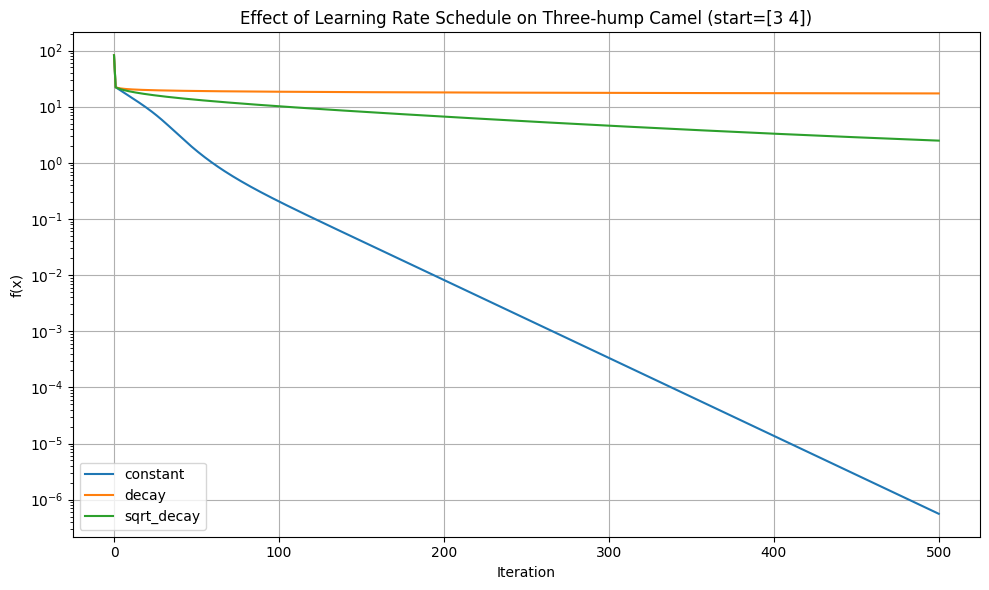

In [7]:
x0 = np.array([3, 4])
schedules = ['constant', 'decay', 'sqrt_decay']

# --- Three-hump camel ---
plt.figure(figsize=(10, 6))
for schedule in schedules:
    x_min, f_vals, path = gradient_descent(f_camel, x0, max_iter=500, lr=0.01, lr_schedule=schedule)
    plt.plot(f_vals, label=f'{schedule}')
    print(f"Camel | {schedule} -> found min at {np.round(x_min, 4)}, f={f_camel(x_min):.6f}")

plt.xlabel('Iteration')
plt.ylabel('f(x)')
plt.title(f'Effect of Learning Rate Schedule on Three-hump Camel (start={x0})')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretation (Three-hump camel):**
The three-hump camel function is close to quadratic near its minimum, so gradient descent converges smoothly regardless of the schedule.

- **Constant** learning rate converges the fastest because the step size remains large enough throughout all iterations to make steady progress toward the minimum.
- **sqrt_decay** ($\gamma_m = \gamma / \sqrt{m}$) converges more slowly: the decreasing step size reduces the speed of descent, but the function value still decreases monotonically.
- **decay** ($\gamma_m = \gamma / m$) converges the slowest. The step size shrinks too aggressively, so the algorithm nearly stalls after the first few iterations and barely makes further progress within 500 steps.

For a well-behaved, nearly quadratic function like the three-hump camel, a constant learning rate is the most efficient choice. Decaying schedules are overly conservative here and slow down convergence without any benefit, since the constant rate does not cause oscillations.

Converged in 500 iterations
Lévi  | constant -> found min at [2.9776 0.8831], f=7.086218
Converged in 500 iterations
Lévi  | decay -> found min at [2.9504 4.4752], f=19.975010
Converged in 65 iterations
Lévi  | sqrt_decay -> found min at [2.9503 4.4752], f=19.975009


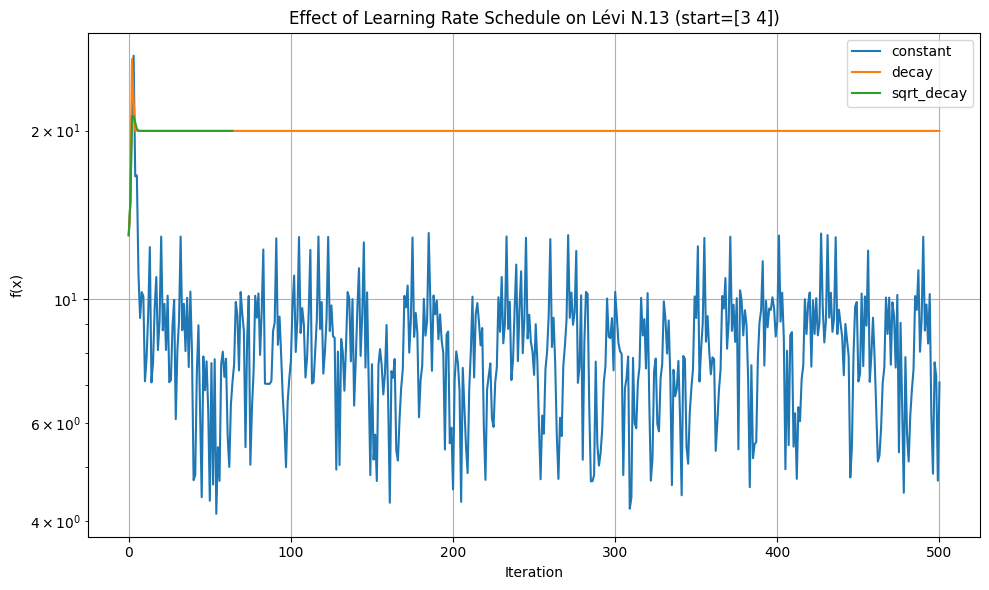

In [8]:
# --- Lévi function N.13 ---
plt.figure(figsize=(10, 6))
for schedule in schedules:
    x_min, f_vals, path = gradient_descent(f_xy, x0, max_iter=500, lr=0.01, lr_schedule=schedule)
    plt.plot(f_vals, label=f'{schedule}')
    print(f"Lévi  | {schedule} -> found min at {np.round(x_min, 4)}, f={f_xy(x_min):.6f}")

plt.xlabel('Iteration')
plt.ylabel('f(x)')
plt.title(f'Effect of Learning Rate Schedule on Lévi N.13 (start={x0})')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretation (Lévi N.13):**
The Lévi function is highly multimodal due to its sinusoidal terms, which creates a landscape full of local minima and ridges.

- **Constant** learning rate shows strong oscillations: the fixed step size causes the iterates to overshoot across the "hills" created by the sin terms, repeatedly jumping between regions before eventually settling. Despite the oscillations, it can still reach a low function value because the large steps allow it to escape shallow local minima.
- **sqrt_decay** ($\gamma_m = \gamma / \sqrt{m}$) offers a good compromise: the step size starts large enough to make progress but gradually shrinks, which dampens the oscillations over time and leads to smoother convergence in later iterations.
- **decay** ($\gamma_m = \gamma / m$) reduces the step size too quickly. The algorithm may get trapped in a local minimum early on, since after a few iterations the steps become too small to escape the sinusoidal ridges.

Unlike the smooth camel function, the Lévi function benefits from a decaying schedule: starting with large steps helps escape local minima, while gradually reducing the rate stabilizes convergence. The sqrt_decay schedule tends to strike the best balance between exploration and convergence on this type of multimodal landscape.

## 6. Discussion of Stopping Criteria


Currently, the code implements the gradient norm criterion: the algorithm stops when ‖∇f(a)‖ < ε for a small tolerance ε > 0.
Beyond this, two alternative stopping criteria could be proposed:

1. Small change in function value: Stop when |f(a_m) − f(a_{m−1})| < ε. If the function value barely changes between consecutive iterations, further iterations are unlikely to yield meaningful improvement.
2. Small change in the iterate: Stop when ‖x_m − x_{m−1}‖ < ε. If the point itself is no longer moving significantly, the algorithm has effectively converged.

In practice, one can combine multiple criteria — for instance, stop when either the maximum number of iterations is reached or the gradient norm falls below the tolerance. 